In [2]:
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from diffPLOG2TROE.rate_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## OH+NO

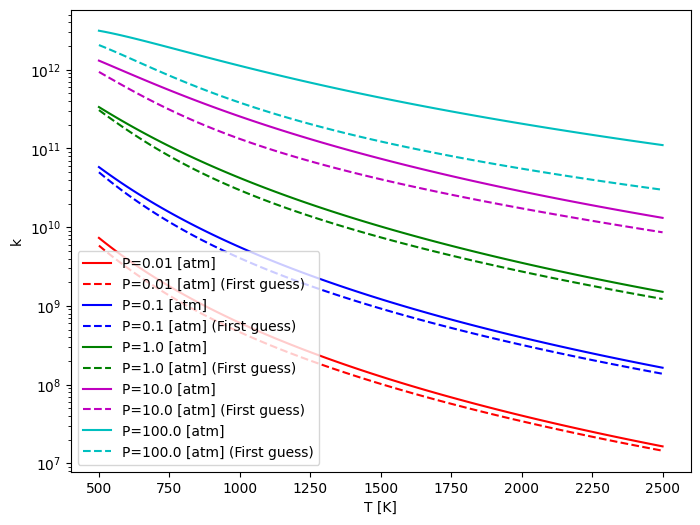

In [20]:
plog = {
    "name": "OH+NO(+M)=OHNO(+M)",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [0.01, 5.020000e+21, -4.24, 898.9],
            [0.1,  5.310000e+22, -4.24, 1184.0],
            [0.316,1.380000e+23, -4.22, 1376.0],
            [1.0,  3.090000e+23, -4.17, 1621.0],
            [3.16, 5.450000e+23, -4.09, 1911.0],
            [10.0, 6.350000e+23, -3.97, 2222.0],
            [31.6, 3.680000e+23, -3.75, 2501.0],
            [100.0,7.290000e+22, -3.41, 2660.0]
        ]
    }
}
constant = Plog(plog)

# These values are the one computed directly by the refitter class as its shown in the next cells
troe = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    hpl_params=jnp.array([7.290e+22, -3.410, 2.660e+03]),
    lpl_params=jnp.array([4.119e+25, -3.240, 8.989e+02]),
    falloff_params=jnp.array([0.500, 1.050e+03, 3.000e+02, 2.250e+03, 0.]),
    falloff_type=1
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.01), jnp.log10(100), 100)
P_levels = jnp.array([0.01, 0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (First guess)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

Known that the high pressure limit for this reaction has been measured when we are going to refit its values into a TROE we are going to fix these values consistently

In [16]:
refitter = PlogRefitter(
    plog_dict=plog,
    T_range=(500, 2500),
    P_range=(0.01, 100),
    fitting_mode="single",
    primary_falloff_type="troe",
    log_name="OH_NO__OHNO.log"
)
results = refitter.optimize(
    max_iterations=3000,
    uncertainty_factor=0.5,
    uncertainty_type="symmetric",
    tol=1e-10
)

Plog to troe refitter
 Temperature range [K]: (500, 2500)
 Pressure range [atm]: (0.01, 100)
 Loss function: rmsle

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: optimizing from default initial value
  n_high: optimizing from default initial value
  E_high: optimizing from default initial value
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Estimating initial parameters:
Troe parameters
  High pressure limit (A, n, Ea): 7.290e+22, -3.410, 2.660e+03
  Low pressure limit (A, n, Ea): 4.119e+25, -3.240, 8.989e+02
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03


Calculating optimization bounds (uncertainty factor: 0.5)

Bounds for Arrhenius parameters (high pressure limit):
  A_high: 1.665e+01 ≤ 5.264e+01 ≤ 1

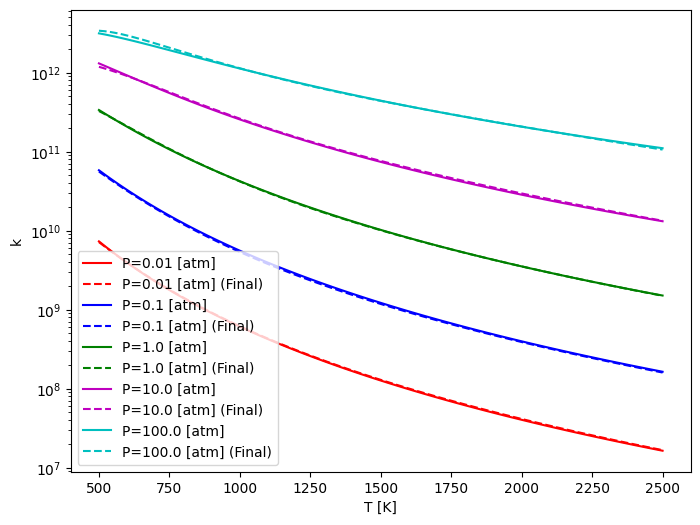

OH+NO(+M)=OHNO(+M)		2.70039e+18 -1.46036 3.58020e+03
 LOW / 		1.19695e+27 -3.63276 1.40651e+03 /
 TROE / 7.43198e-01 2.28637e+03 1.68394e+02 4.29228e+03 /


In [17]:
params = results["optimized_params"]
troe = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    falloff_params=jnp.array([params[6], params[7], params[8], params[9], 0]),
    falloff_type=1
)

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()
print(troe)

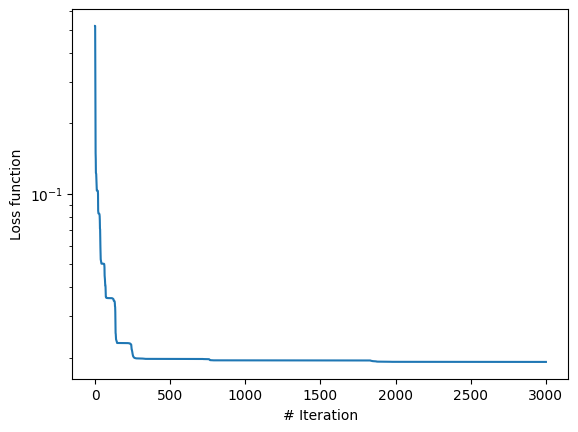

In [18]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()

Minimum error: 0.8958579085704692
Maximum error: 1.119820925564644
Average error: 0.014763708461125562


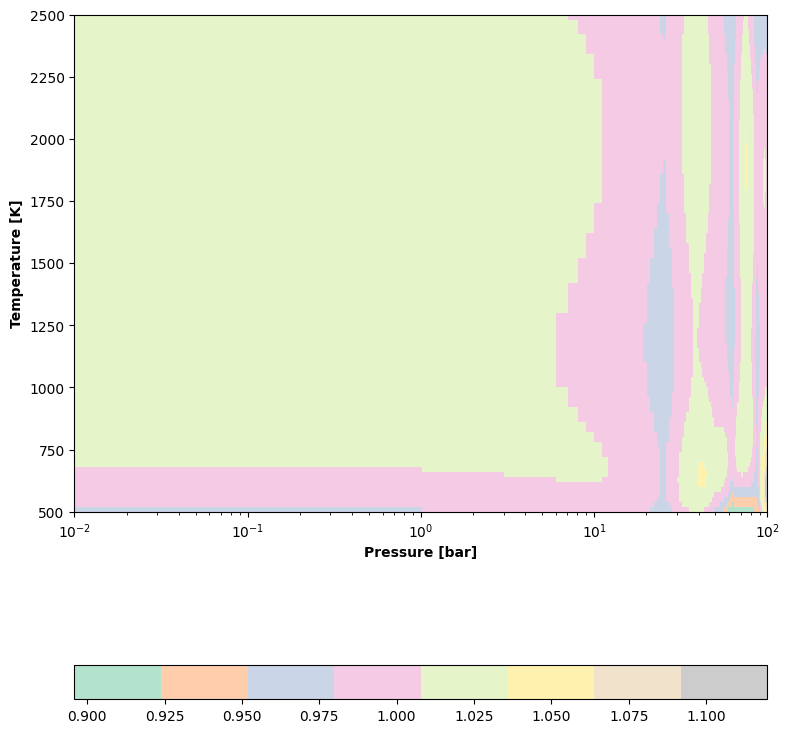

In [19]:
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = constant.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)

ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()